In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/tomsalm/rossmann-processado/rossmann_processado (1).csv


In [2]:
import os
os.makedirs("/kaggle/working/figures", exist_ok=True)

# Milestone 3 - Modelação

In [3]:
import pandas as pd
import numpy as np

# Carregar o dataset processado no M2
caminho = "/kaggle/input/datasets/tomsalm/rossmann-processado/rossmann_processado (1).csv"
df = pd.read_csv(caminho)

# Converter as colunas booleanas do One-Hot Encoding para inteiros (0 e 1)
colunas_bool = df.select_dtypes(include="bool").columns
df[colunas_bool] = df[colunas_bool].astype(int)

print("Dimensão do dataset:", df.shape)
print("\nTipos de dados após conversão:")
print(df.dtypes)
df.head()

Dimensão do dataset: (1017155, 24)

Tipos de dados após conversão:
Store                          int64
DayOfWeek                      int64
Sales                          int64
Promo                          int64
SchoolHoliday                  int64
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
Ano                            int64
Dia                            int64
SemanaDoAno                    int64
FimDeSemana                    int64
Promo2Ativa                    int64
StoreType_b                    int64
StoreType_c                    int64
StoreType_d                    int64
Assortment_b                   int64
Assortment_c                   int64
StateHoliday_a                 int64
StateHoliday_b                 int64
StateHoliday_c                 int64
dtype: object


,Store,DayOfWeek,Sales,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,...,FimDeSemana,Promo2Ativa,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,5263,1,1,1270.0,9.0,2008.0,0,0.0,...,0,0,0,1,0,0,0,0,0,0
1,2,5,6064,1,1,570.0,11.0,2007.0,1,13.0,...,0,1,0,0,0,0,0,0,0,0
2,3,5,8314,1,1,14130.0,12.0,2006.0,1,14.0,...,0,1,0,0,0,0,0,0,0,0
3,4,5,13995,1,1,620.0,9.0,2009.0,0,0.0,...,0,0,0,1,0,0,1,0,0,0
4,5,5,4822,1,1,29910.0,4.0,2015.0,0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 1. Filtrar apenas os dias de loja aberta
# Como removemos a coluna Open no M2, usamos o facto de que dias fechados têm Sales = 0.
# Mantemos apenas os registos com vendas positivas (dias de funcionamento real).
df = df[df["Sales"] > 0].copy()
print("Registos após filtrar dias com vendas:", df.shape[0])

Registos após filtrar dias com vendas: 844338


In [5]:
# 2. Transformação logarítmica da variável alvo
# As vendas têm forte assimetria positiva (visto no M2). O logaritmo aproxima a
# distribuição de uma forma mais simétrica, ajudando o modelo. Usamos log1p
# (logaritmo de 1+x) por segurança numérica.
df["Sales_log"] = np.log1p(df["Sales"])

In [6]:
# Divisão temporal: treino com dados mais antigos, teste com os mais recentes
# Ordenamos por Ano e SemanaDoAno para recuperar a ordem cronológica
df = df.sort_values(by=["Ano", "SemanaDoAno"]).reset_index(drop=True)

# Definimos o ponto de corte de forma a reservar aproximadamente 20% dos dados
# mais recentes para teste, mantendo a ordem temporal (sem fuga de informação)
ponto_corte = int(len(df) * 0.80)

treino = df.iloc[:ponto_corte]
teste = df.iloc[ponto_corte:]

print("Registos de treino:", treino.shape[0])
print("Registos de teste:", teste.shape[0])
print("Proporção de teste:", round(teste.shape[0] / df.shape[0] * 100, 1), "%")

# Confirmar que a divisão é mesmo temporal (o teste deve ser cronologicamente posterior)
print("\nTreino: do ano", treino["Ano"].min(), "ao ano", treino["Ano"].max())
print("Teste: do ano", teste["Ano"].min(), "ao ano", teste["Ano"].max())

Registos de treino: 675470
Registos de teste: 168868
Proporção de teste: 20.0 %

Treino: do ano 2013 ao ano 2015
Teste: do ano 2015 ao ano 2015


In [7]:
# Definir as colunas que NÃO entram como preditoras
colunas_excluir = ["Sales", "Sales_log", "Store"]

# X = todas as variáveis preditoras; y = o alvo (vendas em escala logarítmica)
X_treino = treino.drop(columns=colunas_excluir)
y_treino = treino["Sales_log"]

X_teste = teste.drop(columns=colunas_excluir)
y_teste = teste["Sales_log"]

# Guardar também as vendas reais do teste (escala original) para avaliação posterior
vendas_reais_teste = teste["Sales"]

print("Dimensão X de treino:", X_treino.shape)
print("Dimensão X de teste:", X_teste.shape)
print("\nVariáveis preditoras usadas:")
print(X_treino.columns.tolist())

Dimensão X de treino: (675470, 22)
Dimensão X de teste: (168868, 22)

Variáveis preditoras usadas:
['DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Ano', 'Dia', 'SemanaDoAno', 'FimDeSemana', 'Promo2Ativa', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c']


## Definição das metricas

## Estratégia de Avaliação

### Divisão dos Dados
A divisão entre treino e teste foi feita de forma temporal, e não aleatória. Os dados foram ordenados cronologicamente e os 80% mais antigos foram usados para treino, reservando os 20% mais recentes para teste. Esta opção evita a fuga de informação (data leakage) que ocorreria se o modelo fosse treinado com dados do futuro para prever o passado. Sendo o objetivo prever vendas futuras, faz sentido que o modelo seja avaliado apenas com dados posteriores aos do treino, simulando a situação real de utilização.

### Métricas Escolhidas
Tratando-se de um problema de regressão, foram escolhidas três métricas complementares, todas calculadas em euros para facilitar a interpretação:

- O RMSPE (erro percentual médio) mede o erro das previsões em percentagem. É a métrica principal por ser comparável entre lojas de dimensões diferentes, já que um erro de 100 euros é grave numa loja pequena mas pouco relevante numa loja grande.
- O MAE (erro médio absoluto) indica, em euros, o quanto as previsões se afastam em média das vendas reais, sendo a métrica mais fácil de explicar a qualquer pessoa.
- O R² (coeficiente de determinação) mede a proporção da variação das vendas que o modelo consegue explicar.

A utilização de mais do que uma métrica permite uma escolha mais fundamentada do modelo final, evitando depender de um único indicador.

In [8]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# RMSPE: Root Mean Square Percentage Error (a métrica oficial da competição Rossmann)
# Mede o erro médio em percentagem. Não vem no scikit-learn, por isso definimo-la.
# Ignoramos casos de vendas zero para evitar divisão por zero (já filtrados, mas por segurança).
def rmspe(y_real, y_previsto):
    mascara = y_real != 0
    return np.sqrt(np.mean(((y_real[mascara] - y_previsto[mascara]) / y_real[mascara]) ** 2))

# Função auxiliar para avaliar um modelo nas três métricas, em escala original (euros)
def avaliar_modelo(nome, y_real, y_previsto_log):
    # Reverter a transformação logarítmica para voltar à escala de euros
    y_previsto = np.expm1(y_previsto_log)
    y_real_orig = np.expm1(y_real)

    rmspe_valor = rmspe(y_real_orig.values, y_previsto)
    mae_valor = mean_absolute_error(y_real_orig, y_previsto)
    r2_valor = r2_score(y_real_orig, y_previsto)

    print(f"=== {nome} ===")
    print(f"RMSPE: {rmspe_valor*100:.2f}%")
    print(f"MAE:   {mae_valor:.2f} euros")
    print(f"R²:    {r2_valor:.4f}")
    print()
    return {"modelo": nome, "RMSPE": rmspe_valor, "MAE": mae_valor, "R2": r2_valor}

In [9]:
from sklearn.linear_model import LinearRegression

# Modelo baseline: Regressão Linear
# Serve como ponto de comparação mínimo. Se os modelos mais complexos não
# superarem este, a complexidade adicional não se justifica.
modelo_baseline = LinearRegression()
modelo_baseline.fit(X_treino, y_treino)

# Prever no conjunto de teste (lembrar: as previsões saem em escala logarítmica)
previsoes_baseline = modelo_baseline.predict(X_teste)

# Avaliar usando a função que definimos (que reverte o logaritmo para euros)
resultado_baseline = avaliar_modelo("Baseline - Regressão Linear", y_teste, previsoes_baseline)

=== Baseline - Regressão Linear ===
RMSPE: 41.42%
MAE:   1929.05 euros
R²:    0.2008



## Modelo Baseline: Regressão Linear

Como ponto de partida, treinou-se um modelo de Regressão Linear simples, para estabelecer o patamar mínimo de desempenho. Todos os modelos seguintes terão de superar estes valores para justificarem a sua complexidade.

Os resultados obtidos no conjunto de teste foram os seguintes:

| Métrica | Valor |
| :--- | :--- |
| RMSPE | 41,42% |
| MAE | 1929,05 euros |
| R² | 0,2008 |

Estes valores são fracos, o que era esperado. O R² indica que a regressão linear apenas consegue explicar cerca de 20% da variação das vendas, e o erro médio das previsões ronda os 1929 euros. Este resultado é coerente com a análise exploratória da fase anterior, que mostrou que as relações entre as variáveis e as vendas não são lineares. Um modelo linear, por construção, não consegue captar essas relações mais complexas.

O baseline cumpre, assim, o seu propósito: confirma que um modelo simples é insuficiente para o problema e estabelece o patamar a superar pelos modelos seguintes, baseados em árvores de decisão.

In [10]:
from sklearn.ensemble import RandomForestRegressor
import time

# Random Forest: modelo de conjunto (ensemble) que combina muitas árvores de decisão.
# Capta relações não lineares, ao contrário da regressão linear.
# Usamos parâmetros base nesta fase inicial (a otimização vem depois).
inicio = time.time()
modelo_rf = RandomForestRegressor(
    n_estimators=50,      # número de árvores (50 para ser mais rápido nesta fase inicial)
    max_depth=15,         # profundidade máxima de cada árvore
    n_jobs=-1,            # usar todos os processadores disponíveis (acelera)
    random_state=42       # garante reprodutibilidade
)
modelo_rf.fit(X_treino, y_treino)
print(f"Tempo de treino: {time.time() - inicio:.1f} segundos")

# Avaliar no treino e no teste para detetar overfitting
previsoes_rf_treino = modelo_rf.predict(X_treino)
previsoes_rf_teste = modelo_rf.predict(X_teste)

print("\n--- Desempenho no TREINO ---")
resultado_rf_treino = avaliar_modelo("Random Forest (Treino)", y_treino, previsoes_rf_treino)
print("--- Desempenho no TESTE ---")
resultado_rf_teste = avaliar_modelo("Random Forest (Teste)", y_teste, previsoes_rf_teste)

Tempo de treino: 49.1 segundos

--- Desempenho no TREINO ---
=== Random Forest (Treino) ===
RMSPE: 27.93%
MAE:   1124.04 euros
R²:    0.7188

--- Desempenho no TESTE ---
=== Random Forest (Teste) ===
RMSPE: 25.08%
MAE:   1238.39 euros
R²:    0.6428



In [11]:
from xgboost import XGBRegressor
import time

# XGBoost: outro modelo de conjunto, baseado em boosting (as árvores corrigem
# os erros umas das outras de forma sequencial). Costuma ter bom desempenho
# em problemas tabulares como este.
inicio = time.time()
modelo_xgb = XGBRegressor(
    n_estimators=100,     # número de árvores
    max_depth=8,          # profundidade máxima
    learning_rate=0.1,    # taxa de aprendizagem
    n_jobs=-1,
    random_state=42
)
modelo_xgb.fit(X_treino, y_treino)
print(f"Tempo de treino: {time.time() - inicio:.1f} segundos")

# Avaliar no treino e no teste
previsoes_xgb_treino = modelo_xgb.predict(X_treino)
previsoes_xgb_teste = modelo_xgb.predict(X_teste)

print("\n--- Desempenho no TREINO ---")
resultado_xgb_treino = avaliar_modelo("XGBoost (Treino)", y_treino, previsoes_xgb_treino)
print("--- Desempenho no TESTE ---")
resultado_xgb_teste = avaliar_modelo("XGBoost (Teste)", y_teste, previsoes_xgb_teste)

Tempo de treino: 3.9 segundos

--- Desempenho no TREINO ---
=== XGBoost (Treino) ===
RMSPE: 27.04%
MAE:   1025.48 euros
R²:    0.7718

--- Desempenho no TESTE ---
=== XGBoost (Teste) ===
RMSPE: 22.72%
MAE:   1163.49 euros
R²:    0.6926



In [12]:
import pandas as pd

# Reunir os resultados de todos os modelos numa tabela comparativa
comparacao = pd.DataFrame([
    {"Modelo": "Regressão Linear (Baseline)", "Conjunto": "Teste",
     "RMSPE (%)": 41.42, "MAE (euros)": 1929.05, "R²": 0.2008},
    {"Modelo": "Random Forest", "Conjunto": "Treino",
     "RMSPE (%)": 27.93, "MAE (euros)": 1124.04, "R²": 0.7188},
    {"Modelo": "Random Forest", "Conjunto": "Teste",
     "RMSPE (%)": 25.08, "MAE (euros)": 1238.39, "R²": 0.6428},
    {"Modelo": "XGBoost", "Conjunto": "Treino",
     "RMSPE (%)": 27.04, "MAE (euros)": 1025.48, "R²": 0.7718},
    {"Modelo": "XGBoost", "Conjunto": "Teste",
     "RMSPE (%)": 22.72, "MAE (euros)": 1163.49, "R²": 0.6926},
])

print(comparacao.to_string(index=False))

                     Modelo Conjunto  RMSPE (%)  MAE (euros)     R²
Regressão Linear (Baseline)    Teste      41.42      1929.05 0.2008
              Random Forest   Treino      27.93      1124.04 0.7188
              Random Forest    Teste      25.08      1238.39 0.6428
                    XGBoost   Treino      27.04      1025.48 0.7718
                    XGBoost    Teste      22.72      1163.49 0.6926


## Comparação de Desempenho dos Modelos

| Modelo                      | Conjunto | RMSPE (%) | MAE (euros) | R²     |
| :-------------------------- | :------- | :-------: | :---------: | :----: |
| Regressão Linear (Baseline) | Teste    | 41,42%    | 1929,05 €   | 0,2008 |
| Random Forest               | Treino   | 27,93%    | 1124,04 €   | 0,7188 |
| Random Forest               | Teste    | 25,08%    | 1238,39 €   | 0,6428 |
| XGBoost                     | Treino   | 27,04%    | 1025,48 €   | 0,7718 |
| XGBoost                     | Teste    | 22,72%    | 1163,49 €   | 0,6926 |

## Conclusão

Nesta fase foram treinados e comparados três modelos para prever as vendas diárias das lojas Rossmann: uma Regressão Linear como ponto de partida (baseline), uma Random Forest e um XGBoost. Os dois últimos pertencem a uma família de algoritmos chamada ensemble, que combina várias árvores de decisão para produzir previsões mais fiáveis.

### O que mostram os resultados

O modelo de Regressão Linear serviu apenas como referência mínima. Com um erro médio de cerca de 1929 euros por previsão e um RMSPE de 41,42%, confirmou que as relações simples entre variáveis não chegam para captar os padrões de vendas deste problema. O R² de 0,20 significa que este modelo só consegue explicar 20% da variação das vendas, o que é insuficiente.

Os dois modelos de maior complexidade superaram este patamar. A Random Forest reduziu o erro médio para 1238 euros no conjunto de teste e passou a explicar cerca de 64% da variação das vendas (R² de 0,64). O XGBoost foi ainda mais longe. Com um erro médio de 1163 euros e um RMSPE de 22,72%, é o modelo com melhor desempenho global, explicando cerca de 69% da variação das vendas.

### Existe o risco de o modelo ter decorado os dados

Uma questão importante em qualquer modelo preditivo é perceber se ele aprendeu padrões reais ou se apenas memorizou os dados de treino, situação conhecida como overfitting. Para detetar isso, os modelos foram avaliados tanto nos dados com que foram treinados como em dados novos, o conjunto de teste.

No caso da Random Forest, o desempenho no treino (RMSPE de 27,93%) e no teste (25,08%) é relativamente próximo, o que é um bom sinal. O XGBoost apresenta um padrão semelhante, com 27,04% no treino e 22,72% no teste. O facto de os resultados no teste serem próximos dos do treino indica que os modelos generalizam bem e não estão a decorar os dados.

### Qual o modelo escolhido e porquê

O XGBoost é o modelo que apresenta o melhor equilíbrio entre precisão e capacidade de generalização. Com o menor erro percentual (22,72%), o menor erro médio absoluto (1163 euros) e o R² mais elevado no conjunto de teste (0,69), supera a Random Forest em todas as métricas, sem sinais de overfitting. É, por isso, o modelo escolhido para avançar para a fase de otimização.

Em termos práticos, isto significa que, em média, as previsões do XGBoost para as vendas diárias de uma loja afastam-se cerca de 1163 euros do valor real, uma melhoria clara face ao erro de 1929 euros do modelo mais simples.

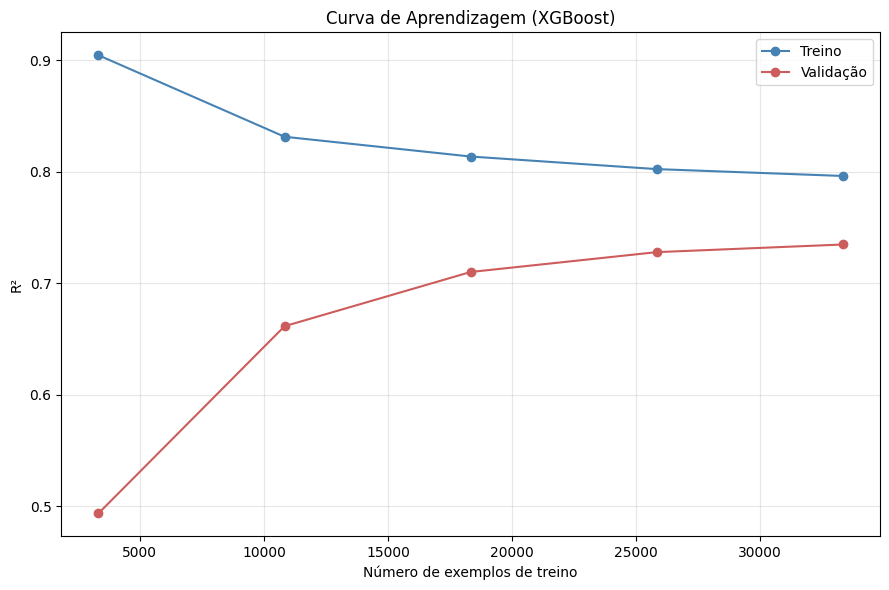

In [13]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# As curvas de aprendizagem treinam o modelo várias vezes, por isso usamos uma
# amostra dos dados de treino para o cálculo ser rápido. O padrão observado numa
# amostra representativa é o mesmo do conjunto completo.
amostra_idx = X_treino.sample(n=50000, random_state=42).index
X_amostra = X_treino.loc[amostra_idx]
y_amostra = y_treino.loc[amostra_idx]

# Usamos o XGBoost, o modelo escolhido. Medimos o erro (R²) para vários tamanhos de treino.
tamanhos, scores_treino, scores_teste = learning_curve(
    modelo_xgb, X_amostra, y_amostra,
    train_sizes=np.linspace(0.1, 1.0, 5),  # 5 pontos: 10%, 32%, 55%, 77%, 100%
    cv=3,                                   # 3 divisões de validação cruzada
    scoring="r2",
    n_jobs=-1
)

# Calcular a média de cada conjunto de scores
media_treino = scores_treino.mean(axis=1)
media_teste = scores_teste.mean(axis=1)

# Desenhar a curva
plt.figure(figsize=(9, 6))
plt.plot(tamanhos, media_treino, "o-", color="steelblue", label="Treino")
plt.plot(tamanhos, media_teste, "o-", color="indianred", label="Validação")
plt.title("Curva de Aprendizagem (XGBoost)")
plt.xlabel("Número de exemplos de treino")
plt.ylabel("R²")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/curva_aprendizagem.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagnóstico de Ajuste e Curva de Aprendizagem

### Comparação entre Treino e Teste
Para avaliar se os modelos aprenderam padrões reais ou apenas memorizaram os dados de treino, comparou-se o desempenho nos dois conjuntos. No XGBoost, o R² foi de 0,77 no treino e de 0,69 no teste. A diferença entre os dois valores é pequena, o que indica um overfitting ligeiro e controlado. Como ambos os valores são razoáveis, não há sinais de underfitting, situação em que o modelo teria um desempenho fraco tanto no treino como no teste.

### Curva de Aprendizagem
A curva de aprendizagem do XGBoost mostra a evolução do desempenho à medida que aumenta a quantidade de dados de treino. Com poucos dados, existe uma grande distância entre a linha de treino e a de validação, sinal de que o modelo se ajustava demasiado aos poucos exemplos disponíveis. À medida que se acrescentam dados, as duas linhas aproximam-se: o desempenho no treino estabiliza e o desempenho na validação sobe de forma clara.

Esta convergência é um bom sinal, pois indica que o modelo generaliza melhor quando dispõe de mais informação. Além disso, a linha de validação ainda apresenta uma ligeira tendência de subida no final, o que sugere que o modelo beneficiaria de uma maior quantidade de dados de treino. Esta observação justifica a utilização do conjunto de dados completo na fase de treino final, em vez de uma amostra reduzida.

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import time

# Usar uma amostra para a pesquisa ser mais rápida (a pesquisa treina o modelo muitas vezes)
amostra_idx = X_treino.sample(n=100000, random_state=42).index
X_busca = X_treino.loc[amostra_idx]
y_busca = y_treino.loc[amostra_idx]

# Espaço de pesquisa: os parâmetros mais influentes do XGBoost
espaco_parametros = {
    "n_estimators": [100, 200, 300, 500],      # número de árvores
    "max_depth": [6, 8, 10, 12],               # profundidade máxima
    "learning_rate": [0.05, 0.1, 0.2],         # taxa de aprendizagem
    "subsample": [0.8, 1.0],                    # fração de dados por árvore
}

# RandomizedSearch: testa 15 combinações aleatórias, com validação cruzada de 5 dobras
busca = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=espaco_parametros,
    n_iter=15,              # número de combinações a testar
    cv=5,                   # validação cruzada com 5 dobras (K=5)
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

inicio = time.time()
busca.fit(X_busca, y_busca)
print(f"\nTempo de pesquisa: {(time.time() - inicio)/60:.1f} minutos")

print("\nMelhores parâmetros encontrados:")
print(busca.best_params_)
print(f"\nMelhor R² na validação cruzada: {busca.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Tempo de pesquisa: 2.9 minutos

Melhores parâmetros encontrados:
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2}

Melhor R² na validação cruzada: 0.9199


## Observação 
Foi feito uma primeira analise com preditores e de forma mais simples para conseguir perceber se o modelo seria bem otimizado com menores preditores.

Deu para perceber que os melhores hiperparametros eram os extremos, ou seja, vamos realizar uma 2ª busca para perceber se existe algum melhor hiperparametro ou se já descobrimos a melhor otimização 

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import time

# Amostra um pouco menor para esta pesquisa mais pesada
amostra_idx_2 = X_treino.sample(n=60000, random_state=42).index
X_busca_2 = X_treino.loc[amostra_idx_2]
y_busca_2 = y_treino.loc[amostra_idx_2]

espaco_parametros_2 = {
    "n_estimators": [500, 700, 900, 1200],
    "max_depth": [8, 10, 12],
    "learning_rate": [0.1, 0.2, 0.3],
    "subsample": [0.8, 1.0],
}

# Nota: n_jobs=1 dentro do XGBoost para evitar conflito com o n_jobs do RandomizedSearch
busca_2 = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=1),
    param_distributions=espaco_parametros_2,
    n_iter=15,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

inicio = time.time()
busca_2.fit(X_busca_2, y_busca_2)
print(f"\nTempo de pesquisa: {(time.time() - inicio)/60:.1f} minutos")

print("\nMelhores parâmetros (segunda pesquisa):")
print(busca_2.best_params_)
print(f"Melhor R² na validação cruzada: {busca_2.best_score_:.4f}")
print(f"\nComparação:")
print(f"  Primeira pesquisa: R² = {busca.best_score_:.4f}")
print(f"  Segunda pesquisa:  R² = {busca_2.best_score_:.4f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Tempo de pesquisa: 5.3 minutos

Melhores parâmetros (segunda pesquisa):
{'subsample': 0.8, 'n_estimators': 900, 'max_depth': 8, 'learning_rate': 0.1}
Melhor R² na validação cruzada: 0.9094

Comparação:
  Primeira pesquisa: R² = 0.9199
  Segunda pesquisa:  R² = 0.9094


In [16]:
import numpy as np

# Média e desvio padrão do R² entre as 5 dobras, para o modelo escolhido (primeira pesquisa)
melhor_indice = busca.best_index_
media_cv = busca.cv_results_["mean_test_score"][melhor_indice]
desvio_cv = busca.cv_results_["std_test_score"][melhor_indice]

print(f"R² médio nas 5 dobras: {media_cv:.4f}")
print(f"Desvio padrão entre dobras: {desvio_cv:.4f}")

R² médio nas 5 dobras: 0.9199
Desvio padrão entre dobras: 0.0021


In [17]:
from xgboost import XGBRegressor
import time

# Parâmetros finais escolhidos (primeira pesquisa: melhor desempenho e mais simples)
parametros_finais = {
    "subsample": 1.0,
    "n_estimators": 500,
    "max_depth": 8,
    "learning_rate": 0.2
}

# Treinar o modelo final no conjunto de treino COMPLETO (675 mil linhas, não a amostra)
inicio = time.time()
modelo_final = XGBRegressor(**parametros_finais, random_state=42, n_jobs=-1)
modelo_final.fit(X_treino, y_treino)
print(f"Tempo de treino: {(time.time() - inicio)/60:.1f} minutos")

# Avaliar no treino e no teste real
previsoes_final_treino = modelo_final.predict(X_treino)
previsoes_final_teste = modelo_final.predict(X_teste)

print("\n--- MODELO FINAL OTIMIZADO ---")
resultado_final_treino = avaliar_modelo("XGBoost Otimizado (Treino)", y_treino, previsoes_final_treino)
resultado_final_teste = avaliar_modelo("XGBoost Otimizado (Teste)", y_teste, previsoes_final_teste)

Tempo de treino: 0.3 minutos

--- MODELO FINAL OTIMIZADO ---
=== XGBoost Otimizado (Treino) ===
RMSPE: 12.29%
MAE:   435.92 euros
R²:    0.9557

=== XGBoost Otimizado (Teste) ===
RMSPE: 15.92%
MAE:   761.68 euros
R²:    0.8677



## Modelo Final Otimizado

Após a otimização de hiperparâmetros, o modelo XGBoost final foi treinado no conjunto de treino completo com os melhores parâmetros encontrados (500 árvores, profundidade máxima de 8, taxa de aprendizagem de 0,2 e amostragem total). O desempenho obtido foi o seguinte:

| Métrica | Treino | Teste |
| :--- | :---: | :---: |
| RMSPE | 12,29% | 15,92% |
| MAE | 435,92 € | 761,68 € |
| R² | 0,9557 | 0,8677 |

Os resultados no conjunto de teste cumprem os dois critérios definidos no objetivo SMART: o RMSPE de 15,92% situa-se abaixo do limite de 20%, e o R² de 0,8677 ultrapassa o mínimo de 0,85 estabelecido. O modelo consegue, assim, explicar cerca de 87% da variação das vendas, com um erro médio de aproximadamente 762 euros por previsão.

Comparando treino e teste, observa-se um overfitting ligeiro, com desempenho superior no treino. Esta diferença é moderada e o modelo mantém um desempenho forte no conjunto de teste, o que indica uma boa capacidade de generalização para dados que não foram usados no treino.

A evolução ao longo das várias fases confirma o valor do processo de modelação. O R² subiu de 0,20 no modelo de base (regressão linear) para 0,64 na Random Forest, 0,69 no XGBoost inicial e, finalmente, 0,87 no XGBoost otimizado. Em paralelo, o erro médio das previsões desceu de 1929 euros para 762 euros.

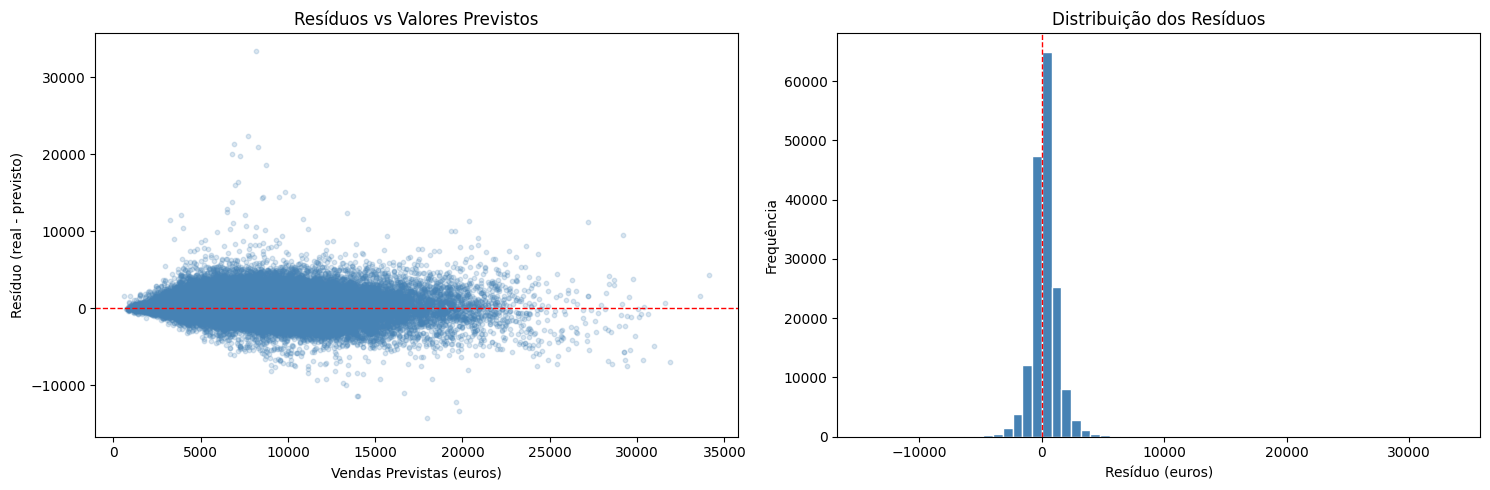

Resíduo médio: 257.94 euros
Desvio padrão dos resíduos: 1083.05 euros


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Reverter as previsões e os valores reais do teste para a escala original (euros)
previsoes_euros = np.expm1(previsoes_final_teste)
reais_euros = np.expm1(y_teste)

# Calcular os resíduos (erro = valor real menos valor previsto)
residuos = reais_euros - previsoes_euros

# Gráfico 1: Resíduos vs Valores Previstos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(previsoes_euros, residuos, alpha=0.2, s=10, color="steelblue")
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Resíduos vs Valores Previstos")
axes[0].set_xlabel("Vendas Previstas (euros)")
axes[0].set_ylabel("Resíduo (real - previsto)")

# Gráfico 2: Distribuição dos resíduos (histograma)
axes[1].hist(residuos, bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduo (euros)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.savefig("/kaggle/working/figures/analise_residuos.png", dpi=150, bbox_inches="tight")
plt.show()

# Estatísticas dos resíduos
print("Resíduo médio:", round(residuos.mean(), 2), "euros")
print("Desvio padrão dos resíduos:", round(residuos.std(), 2), "euros")

In [19]:
import pandas as pd

# Juntar os dados de teste com os resíduos para analisar onde o modelo falha mais
analise = X_teste.copy()
analise["venda_real"] = reais_euros.values
analise["venda_prevista"] = previsoes_euros
analise["erro_absoluto"] = np.abs(residuos.values)
analise["erro_percentual"] = np.abs(residuos.values / reais_euros.values) * 100

# Onde estão os 5% de piores previsões?
limite_erro = analise["erro_percentual"].quantile(0.95)
piores = analise[analise["erro_percentual"] > limite_erro]

print("Características das piores previsões (5% com maior erro):")
print(f"Erro percentual médio nas piores: {piores['erro_percentual'].mean():.1f}%")
print(f"\nVenda real média nas piores: {piores['venda_real'].mean():.0f} euros")
print(f"Venda real média no geral: {analise['venda_real'].mean():.0f} euros")
print(f"\nPromoção ativa nas piores: {piores['Promo'].mean()*100:.0f}% dos casos")
print(f"Promoção ativa no geral: {analise['Promo'].mean()*100:.0f}% dos casos")
print(f"\nFim de semana nas piores: {piores['FimDeSemana'].mean()*100:.0f}% dos casos")
print(f"Fim de semana no geral: {analise['FimDeSemana'].mean()*100:.0f}% dos casos")

Características das piores previsões (5% com maior erro):
Erro percentual médio nas piores: 41.4%

Venda real média nas piores: 6935 euros
Venda real média no geral: 7128 euros

Promoção ativa nas piores: 49% dos casos
Promoção ativa no geral: 45% dos casos

Fim de semana nas piores: 24% dos casos
Fim de semana no geral: 17% dos casos


## Análise de Resíduos e Diagnóstico de Erros

### Análise dos Resíduos
O gráfico dos resíduos em função das vendas previstas mostra que os erros se concentram em torno do zero, o que indica que o modelo acerta na maioria das previsões. Observa-se, no entanto, que a dispersão dos resíduos aumenta à medida que as vendas previstas crescem, formando um padrão em funil. Isto significa que o modelo é mais preciso nas lojas com vendas baixas e médias e tende a errar mais, em valor absoluto, nas lojas com vendas mais elevadas.

A distribuição dos resíduos apresenta uma forma aproximadamente simétrica e centrada perto do zero. O resíduo médio é de cerca de 258 euros, ligeiramente positivo, o que indica que o modelo tende a subestimar muito ligeiramente as vendas reais. Este viés é pequeno face ao valor médio das vendas e não compromete a utilidade do modelo.

### Onde o Modelo Falha
Para perceber em que situações o modelo erra mais, isolaram-se os 5% de previsões com maior erro percentual, que apresentam um erro médio de 41%. A análise destas falhas revelou um padrão claro: os dias de fim de semana estão sobre-representados nas piores previsões, correspondendo a 24% dos casos, contra 17% no conjunto geral. 

Este resultado é coerente com a análise exploratória da fase anterior, que já tinha identificado um comportamento mais irregular das vendas ao fim de semana, sobretudo ao domingo, devido ao encerramento de muitas lojas. O modelo tem, assim, mais dificuldade em prever as vendas nestes dias atípicos. A presença de promoção apresenta uma diferença muito ligeira entre as piores previsões e o conjunto geral, pelo que não constitui um padrão de falha relevante.

Esta análise mostra que a principal limitação do modelo se encontra nos dias de fim de semana e nas lojas de vendas muito elevadas, informação útil para uma utilização consciente das previsões.

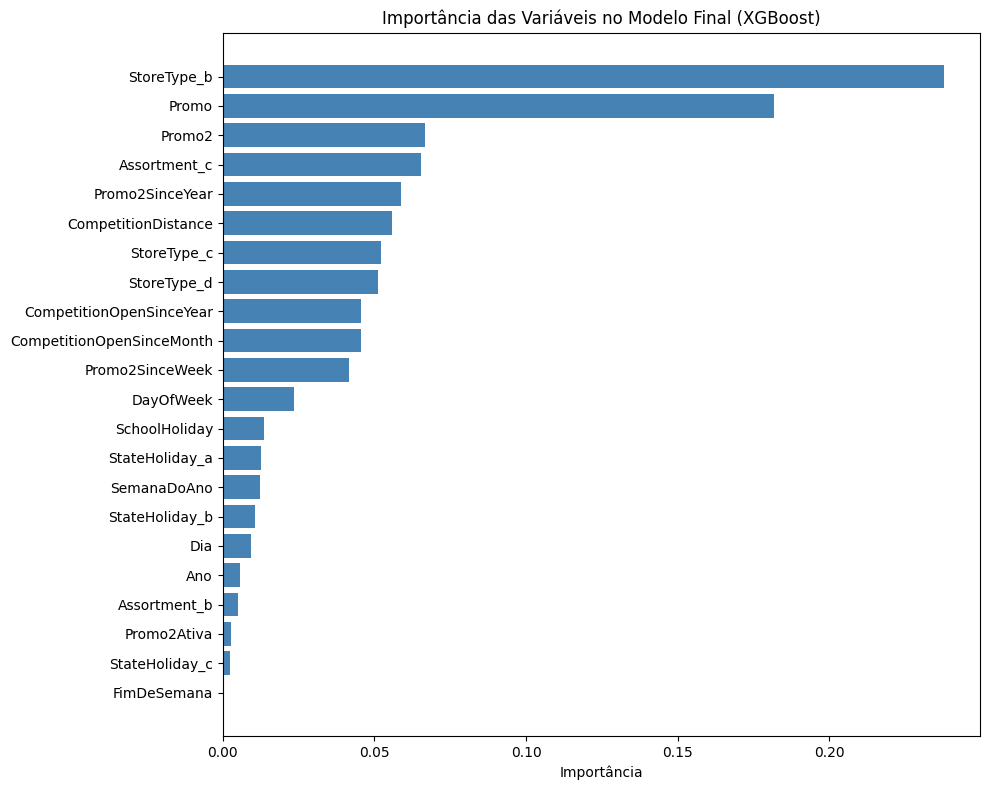

Importância das variáveis (ordenada):
                 variavel  importancia
              StoreType_b     0.237762
                    Promo     0.181741
                   Promo2     0.066681
             Assortment_c     0.065473
          Promo2SinceYear     0.058854
      CompetitionDistance     0.055640
              StoreType_c     0.052222
              StoreType_d     0.051128
 CompetitionOpenSinceYear     0.045655
CompetitionOpenSinceMonth     0.045416
          Promo2SinceWeek     0.041455
                DayOfWeek     0.023510
            SchoolHoliday     0.013670
           StateHoliday_a     0.012732
              SemanaDoAno     0.012280
           StateHoliday_b     0.010731
                      Dia     0.009334
                      Ano     0.005637
             Assortment_b     0.004927
              Promo2Ativa     0.002790
           StateHoliday_c     0.002363
              FimDeSemana     0.000000


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Extrair a importância de cada variável do modelo final
importancias = pd.DataFrame({
    "variavel": X_treino.columns,
    "importancia": modelo_final.feature_importances_
}).sort_values("importancia", ascending=False)

# Gráfico das variáveis mais importantes
plt.figure(figsize=(10, 8))
plt.barh(importancias["variavel"], importancias["importancia"], color="steelblue")
plt.gca().invert_yaxis()  # a mais importante fica no topo
plt.title("Importância das Variáveis no Modelo Final (XGBoost)")
plt.xlabel("Importância")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/importancia_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()

# Mostrar a tabela ordenada
print("Importância das variáveis (ordenada):")
print(importancias.to_string(index=False))

## Importância das Variáveis

A análise da importância das variáveis no modelo final permite responder às perguntas de investigação sobre quais os fatores que mais influenciam as vendas e quais as variáveis que mais contribuem para a previsão.

A variável mais influente é, de longe, o tipo de loja "b" (*StoreType_b*), com uma importância de 0,24. Este resultado confirma de forma clara o padrão identificado na análise exploratória, em que o tipo de loja "b", apesar de ser o menos frequente, era o que apresentava vendas medianas mais elevadas. O modelo veio confirmar que esta é a característica mais determinante para prever as vendas.

A segunda variável mais importante é a promoção (*Promo*), com 0,18, o que confirma o forte efeito das campanhas promocionais já observado na fase exploratória. Seguem-se a adesão à promoção contínua (*Promo2*), a variedade de produtos (*Assortment_c*) e a distância à concorrência, todas com contributos relevantes. No conjunto, são sobretudo o perfil da loja e as promoções que determinam o volume de vendas.

Um resultado que merece destaque é o facto de a variável *FimDeSemana* ter apresentado uma importância nula. Isto não significa que o fim de semana não afete as vendas, mas sim que essa informação já está contida na variável *DayOfWeek*, que distingue os sete dias da semana de forma mais detalhada. Sendo o *FimDeSemana* derivado do *DayOfWeek*, o modelo optou por usar a variável original, mais rica, tornando a criada redundante. De forma semelhante, a variável *Dia* do mês revelou uma importância reduzida, indicando que o dia do mês tem pouca influência na previsão das vendas.

Esta análise demonstra que nem todas as variáveis criadas se revelaram úteis ao modelo, o que constitui em si um resultado válido, ao distinguir as características que realmente contribuem para a previsão daquelas que são redundantes ou pouco informativas.

In [21]:
# ============================================================
# MODELO FINAL DE PRODUÇÃO
# ============================================================
# Modelo escolhido: XGBoost otimizado
# Parâmetros: n_estimators=500, max_depth=8, learning_rate=0.2, subsample=1.0
#
# Justificação da escolha:
# - Desempenho: melhor R² (0,87) e menor RMSPE (15,9%) no conjunto de teste,
#   cumprindo os critérios da meta SMART.
# - Estabilidade: validação cruzada com R² médio de 0,92 e desvio padrão de
#   apenas 0,0021, o que indica resultados consistentes entre dobras.
# - Interpretabilidade: permite extrair a importância das variáveis, ajudando
#   a explicar quais os fatores que mais influenciam as vendas.
# ============================================================

print("Modelo final de produção: XGBoost otimizado")
print("Parâmetros:", parametros_finais)
print("Desempenho no teste -> RMSPE: 15,92% | MAE: 761,68 € | R²: 0,8677")

Modelo final de produção: XGBoost otimizado
Parâmetros: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.2}
Desempenho no teste -> RMSPE: 15,92% | MAE: 761,68 € | R²: 0,8677


## Seleção do Modelo de Produção

O modelo selecionado para produção é o XGBoost otimizado, com 500 árvores, profundidade máxima de 8, taxa de aprendizagem de 0,2 e amostragem total. A escolha assenta no equilíbrio entre três critérios.

Quanto ao desempenho, foi o modelo com melhores métricas no conjunto de teste, com um R² de 0,87 e um RMSPE de 15,92%, cumprindo ambos os critérios definidos no objetivo SMART. Superou claramente o modelo de base (regressão linear) e a Random Forest.

Quanto à estabilidade, a validação cruzada com cinco dobras apresentou um R² médio de 0,92 com um desvio padrão de apenas 0,0021. Este valor muito baixo confirma que o modelo produz resultados consistentes, independentemente da divisão dos dados, não dependendo de uma partição em particular.

Quanto à interpretabilidade, o XGBoost permite extrair a importância de cada variável, o que tornou possível identificar os fatores que mais influenciam as vendas, como o tipo de loja e as promoções. Esta capacidade de explicar as previsões é importante para a aplicação prática do modelo na gestão de inventário.

## Conclusão da Fase de Modelação

A fase de modelação cumpriu o objetivo definido para o projeto. Partindo de um modelo de base simples, foram testados e comparados modelos progressivamente mais sofisticados, com uma melhoria clara do desempenho em cada etapa.

### Evolução do Desempenho

A tabela seguinte resume a progressão dos modelos no conjunto de teste, desde a referência inicial até ao modelo final otimizado.

| Modelo | RMSPE (%) | MAE (euros) | R² |
| :--- | :---: | :---: | :---: |
| Regressão Linear (Baseline) | 41,42% | 1929,05 € | 0,2008 |
| Random Forest | 25,08% | 1238,39 € | 0,6428 |
| XGBoost (base) | 22,72% | 1163,49 € | 0,6926 |
| XGBoost (otimizado) | 15,92% | 761,68 € | 0,8677 |

A progressão é clara: o R² subiu de 0,20 para 0,87 e o erro médio das previsões desceu de 1929 para 762 euros, uma redução de mais de 60%.

### Modelo Final e Hiperparâmetros

O modelo escolhido para produção é o XGBoost otimizado, com os seguintes hiperparâmetros, encontrados por pesquisa aleatória com validação cruzada de cinco dobras:

| Hiperparâmetro | Valor |
| :--- | :---: |
| n_estimators (número de árvores) | 500 |
| max_depth (profundidade máxima) | 8 |
| learning_rate (taxa de aprendizagem) | 0,2 |
| subsample (amostragem) | 1,0 |

A validação cruzada confirmou a estabilidade do modelo, com um R² médio de 0,92 e um desvio padrão de apenas 0,0021 entre as dobras.

### Cumprimento do Objetivo SMART

A tabela seguinte verifica o cumprimento dos critérios definidos no objetivo SMART, medidos no conjunto de teste.

| Critério | Meta | Resultado | Cumprido |
| :--- | :---: | :---: | :---: |
| RMSPE | ≤ 20% | 15,92% | Sim |
| R² | ≥ 0,85 | 0,8677 | Sim |

Ambos os critérios foram cumpridos, com margem em ambos os casos.

### Síntese

O processo seguiu uma metodologia rigorosa, com divisão temporal dos dados para evitar fugas de informação, validação cruzada para garantir a estabilidade, otimização sistemática dos hiperparâmetros e uma análise crítica dos erros e da importância das variáveis. Esta análise identificou o tipo de loja e as promoções como os fatores mais determinantes nas vendas. Foram também reconhecidas as limitações do modelo, sobretudo uma maior dificuldade em prever as vendas nos dias de fim de semana e nas lojas de vendas muito elevadas.

O modelo cumpre os objetivos definidos e encontra-se pronto para a fase final, na qual os resultados serão traduzidos em valor para o negócio.